# VIVA Q&A

<font size="5">
Q1: What is the main goal of Practical 10?
Answer: To predict (forecast) future values for the short term by looking at historical data.

Q2: How does Simple Exponential Smoothing work?
Answer: It predicts the future by giving the most mathematical "weight" (importance) to the most recent data, and less importance to older data.

Q3: Look at your final graph. Why is the green forecast line completely flat (horizontal)?
Answer: Because Simple Exponential Smoothing is a basic model. It does not calculate upward trends or summer spikes; it only calculates a recent baseline and projects it straight forward.

Q4: In your code, what does initialization_method="estimated" do?
Answer: It tells the computer to automatically do the heavy math to find the perfect starting weights for the model so we don't have to guess them.

Q5: Why is this called a "short-term" forecasting method?
Answer: Because it relies only on recent momentum. It is good for guessing what will happen next month, but terrible at guessing what will happen 5 years from now.
</font>

# Practical 10 First Method

--- Practical 10: Short-Term Forecasting (ARIMA) ---
Fetching 'dowjones' stock market dataset...
Fitting the ARIMA Model...
Generating short-term forecast...


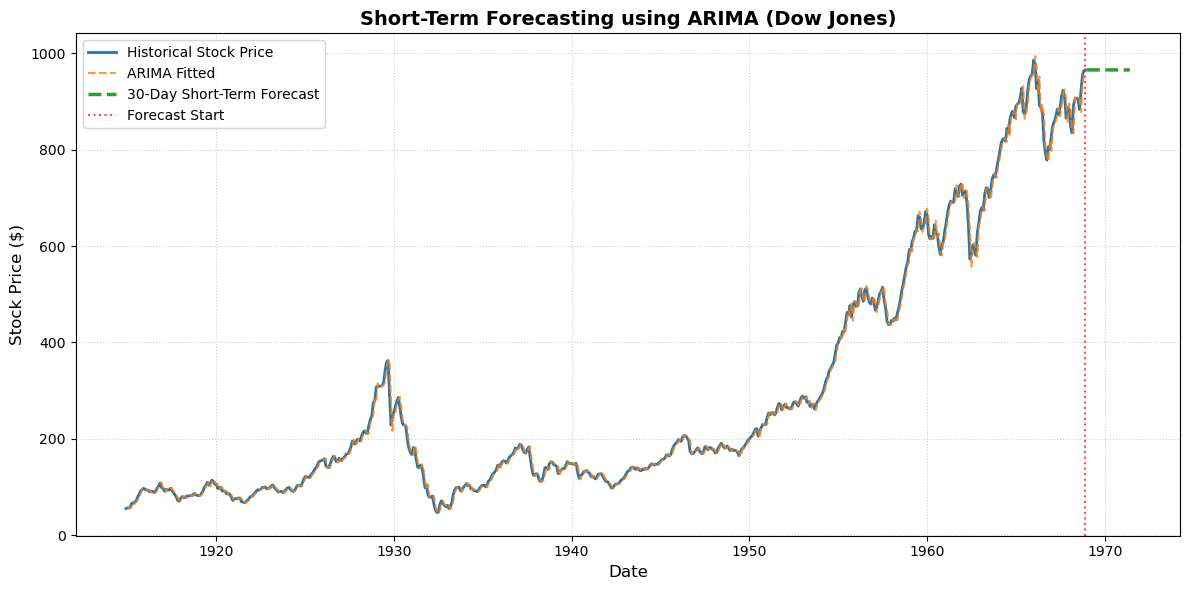


--- Next 30 Days Forecasted Prices ---
            Predicted Price
1969-01-01           965.51
1969-02-01           965.51
1969-03-01           965.51
1969-04-01           965.51
1969-05-01           965.51
1969-06-01           965.51
1969-07-01           965.51
1969-08-01           965.51
1969-09-01           965.51
1969-10-01           965.51
1969-11-01           965.51
1969-12-01           965.51
1970-01-01           965.51
1970-02-01           965.51
1970-03-01           965.51
1970-04-01           965.51
1970-05-01           965.51
1970-06-01           965.51
1970-07-01           965.51
1970-08-01           965.51
1970-09-01           965.51
1970-10-01           965.51
1970-11-01           965.51
1970-12-01           965.51
1971-01-01           965.51
1971-02-01           965.51
1971-03-01           965.51
1971-04-01           965.51
1971-05-01           965.51
1971-06-01           965.51


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress harmless warnings for a clean exam output
warnings.filterwarnings("ignore")

def short_term_forecast():
    print("--- Practical 10: Short-Term Forecasting (ARIMA) ---")
    
    # 1. Load the Dataset
    print("Fetching 'dowjones' stock market dataset...")
    df = sns.load_dataset('dowjones')
    
    # Ensure dates are in the correct format and set as the index
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values(by='Date', ascending=True)
    df.set_index('Date', inplace=True)
    
    # Extract the 'Price' column for our time series
    ts_data = df['Price']

    print("Fitting the ARIMA Model...")
    
    # 2. Define the ARIMA Model
    # order=(p, d, q)
    # p = 1 (Looks 1 step back for Autoregression)
    # d = 1 (Differences the data 1 time to make it stationary)
    # q = 1 (Looks 1 step back for Moving Average noise)
    model = ARIMA(ts_data, order=(1, 1, 1))
    
    # Fit the model to the historical data
    fit_model = model.fit()

    print("Generating short-term forecast...")
    
    # 3. Forecast future values (Short-term: Next 30 periods)
    forecast_steps = 30
    forecast = fit_model.forecast(steps=forecast_steps)

    # 4. Plot the results
    plt.figure(figsize=(12, 6))
    
    # Plot Original Historical Data
    plt.plot(ts_data.index, ts_data, label='Historical Stock Price', color='tab:blue', linewidth=2)
    
    # Plot Fitted Values (How well the model learned the past)
    # We slice [1:] to drop the very first fitted point which is usually 0 due to differencing
    plt.plot(fit_model.fittedvalues.index[1:], fit_model.fittedvalues[1:], 
             label='ARIMA Fitted', color='tab:orange', linestyle='--', alpha=0.8)
    
    # Plot the Short-Term Forecast
    plt.plot(forecast.index, forecast, label='30-Day Short-Term Forecast', color='tab:green', linewidth=2.5, linestyle='--')
    
    # Add a vertical line to show where the forecast begins
    plt.axvline(x=ts_data.index[-1], color='red', linestyle=':', label='Forecast Start', alpha=0.7)
    
    plt.title('Short-Term Forecasting using ARIMA (Dow Jones)', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Stock Price ($)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

    # Print a neat table of the forecasted values
    print("\n--- Next 30 Days Forecasted Prices ---")
    print(forecast.round(2).to_frame(name='Predicted Price'))

if __name__ == "__main__":
    short_term_forecast()

# Practical 10 Second Method 

--- Practical 10: Short-Term Forecasting (Simple Exponential Smoothing) ---
Fetching 'flights' dataset...
Fitting the Simple Exponential Smoothing Model...
Generating short-term forecast...


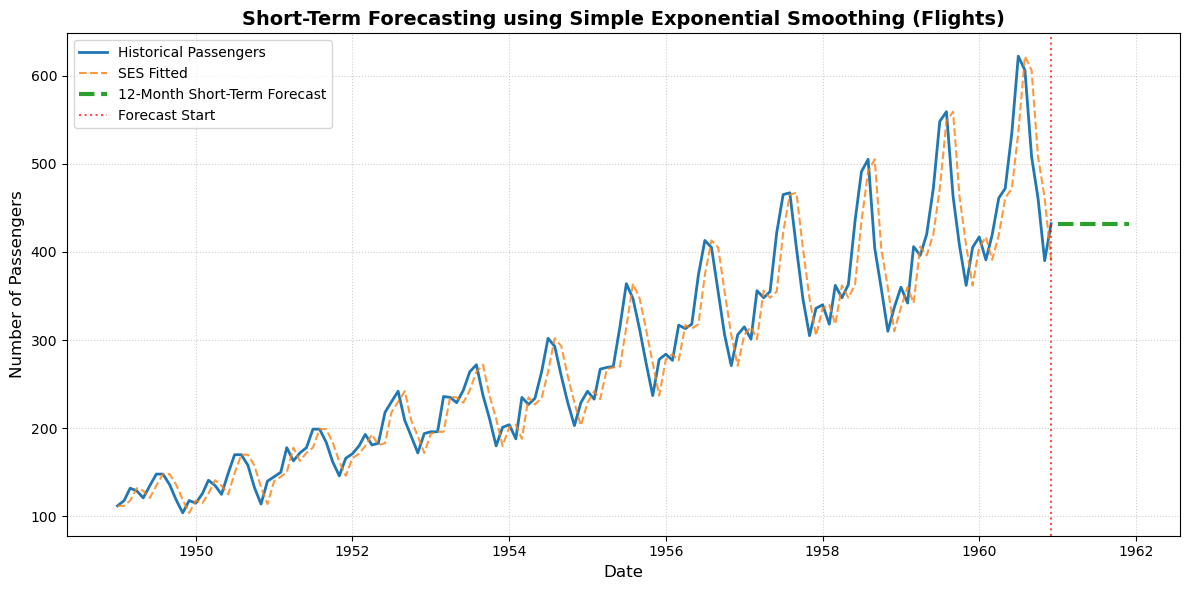


--- Next 12 Months Forecasted Passengers ---
            Predicted Passengers
1961-01-01                 432.0
1961-02-01                 432.0
1961-03-01                 432.0
1961-04-01                 432.0
1961-05-01                 432.0
1961-06-01                 432.0
1961-07-01                 432.0
1961-08-01                 432.0
1961-09-01                 432.0
1961-10-01                 432.0
1961-11-01                 432.0
1961-12-01                 432.0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import warnings

# Suppress harmless warnings for a clean exam output
warnings.filterwarnings("ignore")

def short_term_forecast_es():
    print("--- Practical 10: Short-Term Forecasting (Simple Exponential Smoothing) ---")
    
    # 1. Load the Dataset
    print("Fetching 'flights' dataset...")
    df = sns.load_dataset('flights')
    
    # Ensure dates are in the correct format and set as the index
    df['Date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str))
    df = df.sort_values(by='Date', ascending=True)
    df.set_index('Date', inplace=True)
    
    # Extract the 'passengers' column for our time series
    ts_data = df['passengers']

    print("Fitting the Simple Exponential Smoothing Model...")
    
    # 2. Define and Fit the Model
    # We use SimpleExpSmoothing for a pure short-term baseline forecast
    # initialization_method="estimated" lets the computer find the best starting weights
    model = SimpleExpSmoothing(ts_data, initialization_method="estimated")
    fit_model = model.fit()

    print("Generating short-term forecast...")
    
    # 3. Forecast future values (Short-term: Next 12 months)
    forecast_steps = 12
    forecast = fit_model.forecast(steps=forecast_steps)

    # 4. Plot the results
    plt.figure(figsize=(12, 6))
    
    # Plot Original Historical Data
    plt.plot(ts_data.index, ts_data, label='Historical Passengers', color='tab:blue', linewidth=2)
    
    # Plot Fitted Values (How well the model learned the past)
    plt.plot(fit_model.fittedvalues.index, fit_model.fittedvalues, 
             label='SES Fitted', color='tab:orange', linestyle='--', alpha=0.8)
    
    # Plot the Short-Term Forecast
    plt.plot(forecast.index, forecast, label='12-Month Short-Term Forecast', color='tab:green', linewidth=3, linestyle='--')
    
    # Add a vertical line to show where the forecast begins
    plt.axvline(x=ts_data.index[-1], color='red', linestyle=':', label='Forecast Start', alpha=0.7)
    
    plt.title('Short-Term Forecasting using Simple Exponential Smoothing (Flights)', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Passengers', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

    # Print a neat table of the forecasted values
    print("\n--- Next 12 Months Forecasted Passengers ---")
    print(forecast.round(2).to_frame(name='Predicted Passengers'))

if __name__ == "__main__":
    short_term_forecast_es()